# 가위바위보 이미지를 통해서 분류기 만들기
실험 목표 : 내가 만든 가위바위보 사진을 학습해, 가위바위보를 분류할수있는 모델을 만들어보자

# 실험 정보

## 데이터

### 훈련 데이터
- 웹캠을 통해 직접찍은 왼손 가위바위보 사진 300장
- 기본 제공된 가위바위보 사진 train 300장
- 총 600장
- 28X28로 resize, 이후 표준화 /225

### 테스트 데이터
- 기본 제공된 가위바위보 사진 test 300장

# 사용한 모델
![](./images/rsp_model.png)

# 실험 결과
test_accuracy: 0.4166666567325592
Test Accuracy: 59.67% (VGG16)

# 실험 샘플링을 통한 결과 분석
![](./images/rsp_sample.png)

# 회고
훈련 데이터를 2배로 늘리면 성능이 많이 좋아질 거라 생각했는데 그렇지 않았다.
<br>아마 사용한 모델 입장에서는 300개나 600개나 그게 그거였던 것 같다.  
파라미터도 조금 바꿔봤는데 최적해를 탐색한 것이 아니라
그냥 내 마음대로 숫자를 넣어봐서 얼마나 효과가 있었는지도 잘 모르겠다.
VGG16이라는 모델을 써보니 약간 개선되었으나 마음에 드는 결과는 아니었다.
그리고 데이터의 양보다도 리사이징 크기를 더 크게 해주니 결과가 좋아졌다.


In [34]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)

2.20.0
2.4.1


In [35]:
from PIL import Image 
import glob
import os

print("PIL 라이브러리 import 완료!")

PIL 라이브러리 import 완료!


In [36]:
import glob
import os
from PIL import Image

def resize_images(img_path, save_path):
    # ~ 기호(홈 디렉토리)를 실제 경로로 변환
    full_img_path = os.path.expanduser(img_path)
    full_save_path = os.path.expanduser(save_path)

    # 1. 저장할 디렉토리가 없다면 생성
    if not os.path.exists(full_save_path):
        os.makedirs(full_save_path)

    # 2. 원본 경로에서 jpg 파일 목록 가져오기
    images = glob.glob(full_img_path + "/*.jpg")  
    
    if len(images) == 0:
        print(f"⚠️ [확인 필요] {full_img_path}에 이미지가 없습니다.")
        return

    target_size = (28, 28)
    
    for img in images:
        file_name = os.path.basename(img)
        try:
            old_img = Image.open(img)
            new_img = old_img.resize(target_size, Image.LANCZOS)
            new_img.save(os.path.join(full_save_path, file_name), "JPEG")
        except Exception as e:
            print(f"❌ {file_name} 변환 중 에러 발생: {e}")
    
    print(f"✅ 완료: {len(images)}개의 이미지가 {full_save_path}에 저장되었습니다.")

# --- 메인 실행부 ---

# 공통 기본 경로 설정
base_read_path = '~/vscode/rsp/train/rsp_plus'
base_save_path = '~/vscode/rsp/train/rsp_resize'

# 처리할 폴더 리스트
categories = ['scissor', 'rock', 'paper']

for category in categories:
    # 각 카테고리별 경로 생성
    read_dir = os.path.join(base_read_path, category)
    save_dir = os.path.join(base_save_path, category)
    
    print(f"\n[{category.upper()} 폴더 작업 시작]")
    resize_images(read_dir, save_dir)

print("\n✨ 모든 카테고리 리사이즈 완료!")


[SCISSOR 폴더 작업 시작]
✅ 완료: 200개의 이미지가 /Users/jun/vscode/rsp/train/rsp_resize/scissor에 저장되었습니다.

[ROCK 폴더 작업 시작]
✅ 완료: 200개의 이미지가 /Users/jun/vscode/rsp/train/rsp_resize/rock에 저장되었습니다.

[PAPER 폴더 작업 시작]
✅ 완료: 200개의 이미지가 /Users/jun/vscode/rsp/train/rsp_resize/paper에 저장되었습니다.

✨ 모든 카테고리 리사이즈 완료!


In [38]:
import numpy as np
import glob
import os
from PIL import Image

def load_data(img_path):
    # 1. 먼저 전체 이미지 개수를 세어봅니다.
    # 각 폴더(scissor, rock, paper) 내의 모든 jpg 파일 리스트를 합칩니다.
    image_list = glob.glob(img_path + '/scissor/*.jpg') + \
                 glob.glob(img_path + '/rock/*.jpg') + \
                 glob.glob(img_path + '/paper/*.jpg')
    
    number_of_data = len(image_list)
    
    if number_of_data == 0:
        print("❌ 이미지를 찾을 수 없습니다. 경로를 확인해주세요.")
        return None, None

    # 2. 이미지 개수(number_of_data)만큼 행렬 영역을 생성합니다.
    img_size = 28
    color = 3
    imgs = np.zeros(number_of_data * img_size * img_size * color, dtype=np.int32).reshape(number_of_data, img_size, img_size, color)
    labels = np.zeros(number_of_data, dtype=np.int32)

    idx = 0
    # 3. 실제 이미지를 하나씩 읽어옵니다.
    # 카테고리와 라벨을 딕셔너리로 관리하면 코드가 더 깔끔해집니다.
    categories = {'scissor': 0, 'rock': 1, 'paper': 2}
    
    for category, label in categories.items():
        folder_path = os.path.join(img_path, category)
        for file in glob.iglob(folder_path + '/*.jpg'):
            try:
                img = np.array(Image.open(file), dtype=np.int32)
                imgs[idx, :, :, :] = img    # 데이터 영역에 이미지 행렬 복사
                labels[idx] = label         # 라벨 저장
                idx += 1
            except Exception as e:
                print(f"❌ {file} 로드 중 에러 발생: {e}")

    print(f"성공적으로 {idx}개의 이미지를 불러왔습니다.")
    return imgs, labels

# --- 실행 코드 ---
# 학습 데이터 경로
train_image_dir = os.path.expanduser("~/vscode/rsp/train/rsp_resize")
(x_train, y_train) = load_data(train_image_dir)

if x_train is not None:
    x_train_norm = x_train / 255.0  # 정규화
    print("x_train shape: {}".format(x_train.shape))
    print("y_train shape: {}".format(y_train.shape))

성공적으로 600개의 이미지를 불러왔습니다.
x_train shape: (600, 28, 28, 3)
y_train shape: (600,)


라벨:  0


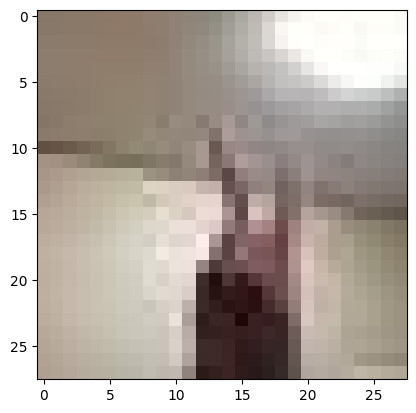

In [39]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
print('라벨: ', y_train[0])

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# model을 직접 만들어 보세요.
# Hint! model의 입력/출력부에 특히 유의해 주세요. 가위바위보 데이터셋은 MNIST 데이터셋과 어떤 점이 달라졌나요?
# 아래의 하이퍼파라미터는 예시입니다. 높은 인식률을 얻기 위해 하이퍼파라미터를 수정해 보세요. 
n_channel_1=32
n_channel_2=64
n_dense=64
n_train_epoch=10

model=keras.models.Sequential()
model.add(keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(28,28,3)))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(n_channel_2, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,051 (476.76 KB)

 Trainable params: 122,051 (476.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model을 학습시키는 코드를 직접 작성해 보세요. 
# Hint! model.compile()과 model.fit()을 사용해 봅시다.
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

# 모델 훈련
model.fit(x_train, y_train, epochs=n_train_epoch)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3617 - loss: 18.4363 
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5400 - loss: 1.0548
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6450 - loss: 0.6910
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7517 - loss: 0.5399
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7583 - loss: 0.5051
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7917 - loss: 0.4471
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8367 - loss: 0.3769
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8933 - loss: 0.3203
Epoch 9/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9067 - loss: 0.2793
Epoch 10/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9283 - loss: 0.2367


In [43]:
import os

# 1. 테스트 이미지 경로 설정 (절대 경로 혹은 ~ 사용)
test_base_path = os.path.expanduser('~/vscode/rsp/test')

# 2. 각 카테고리별로 리사이즈 수행
# 주의: 이 코드는 원본 테스트 이미지를 28x28로 리사이즈하여 덮어씌웁니다.
test_categories = ['scissor', 'rock', 'paper']

for category in test_categories:
    target_path = os.path.join(test_base_path, category)
    # 원본과 저장 경로를 동일하게 설정하여 해당 폴더 내 이미지를 직접 변환합니다.
    resize_images(target_path, target_path)

# 3. load_data 함수를 통해 x_test, y_test 생성
# load_data 함수는 보통 인자로 받은 폴더 하위의 rock, scissor, paper를 찾아 읽습니다.
(x_test, y_test) = load_data(test_base_path)

# 4. 데이터 정규화 (Normalization)
x_test_norm = x_test / 255.0

# 5. 결과 확인
print("x_test shape: {}".format(x_test.shape))
print("y_test shape: {}".format(y_test.shape))

✅ 완료: 100개의 이미지가 /Users/jun/vscode/rsp/test/scissor에 저장되었습니다.
✅ 완료: 100개의 이미지가 /Users/jun/vscode/rsp/test/rock에 저장되었습니다.
✅ 완료: 100개의 이미지가 /Users/jun/vscode/rsp/test/paper에 저장되었습니다.
성공적으로 300개의 이미지를 불러왔습니다.
x_test shape: (300, 28, 28, 3)
y_test shape: (300,)


In [52]:
# model을 학습시키는 코드를 직접 작성해 보세요.
# Hint! model.evaluate()을 사용해 봅시다.
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print("test_loss: {} ".format(test_loss))
print("test_accuracy: {}".format(test_accuracy))

10/10 - 5s - 515ms/step - accuracy: 0.4167 - loss: 35.7207
test_loss: 35.72068786621094 
test_accuracy: 0.4166666567325592


In [48]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import os
import numpy as np

# ====================================================
# [중요] VGG16은 입력 크기가 최소 32x32 이상이어야 함
# 기존 로드된 데이터(x_train, x_test)가 있다면 그대로 사용
# ====================================================

# 1. 데이터 증강 (Augmentation) 강화
# 학습 데이터가 적을 때 배경 변화 등에 강해지도록 이미지를 더 많이 비틉니다.
datagen = ImageDataGenerator(
    rotation_range=30,      # 회전 각도 늘림
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. VGG16 모델 불러오기 (Pre-trained Model)
# include_top=False: 마지막 분류기(1000개 클래스)는 떼고 가져옴
# weights='imagenet': 이미 학습된 가중치를 사용 (핵심!)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(112, 112, 3))

# 기본 모델의 가중치는 학습되지 않도록 고정 (Freeze)
# 이미 똑똑하니까 건드리지 않습니다.
base_model.trainable = False

# 3. 모델 조립
model = models.Sequential([
    base_model,                 # 똑똑한 눈 (특징 추출기)
    layers.Flatten(),           # 1차원으로 펴기
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),        # 과적합 방지
    layers.Dense(3, activation='softmax') # 가위/바위/보 분류
])

# 4. 컴파일 (학습률을 조금 낮게 설정)
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 5. 학습 실행
# x_train_split, y_train_split 등은 이전 단계 변수 사용
print("\n🚀 전이 학습(Transfer Learning) 시작...")

checkpoint_cb = callbacks.ModelCheckpoint('best_vgg_model.h5', save_best_only=True, monitor='val_loss', mode='min')
early_stopping_cb = callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')

history = model.fit(
    datagen.flow(x_train_split, y_train_split, batch_size=32),
    epochs=20,
    validation_data=(x_val_split, y_val_split),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

# 6. 테스트 평가
print("\n--- [최종 평가] ---")
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test, verbose=2)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,895,363 (60.64 MB)

 Trainable params: 1,180,675 (4.50 MB)

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 674ms/step - accuracy: 0.9312 - loss: 0.2581 - val_accuracy: 0.9333 - val_loss: 0.1865
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.9510 - loss: 0.2328

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 699ms/step - accuracy: 0.9375 - loss: 0.2451 - val_accuracy: 0.9417 - val_loss: 0.1598
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.8998 - loss: 0.2803

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 680ms/step - accuracy: 0.9125 - loss: 0.2665 - val_accuracy: 0.9333 - val_loss: 0.1584
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 686ms/step - accuracy: 0.8958 - loss: 0.2577 - val_accuracy: 0.9250 - val_loss: 0.1691
Epoch 15/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9362 - loss: 0.2424

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 703ms/step - accuracy: 0.9458 - loss: 0.2234 - val_accuracy: 0.9583 - val_loss: 0.1298
Epoch 16/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 674ms/step - accuracy: 0.9146 - loss: 0.2525 - val_accuracy: 0.9333 - val_loss: 0.1541
Epoch 17/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 687ms/step - accuracy: 0.9479 - loss: 0.2119 - val_accuracy: 0.9333 - val_loss: 0.1400
Epoch 18/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 665ms/step - accuracy: 0.9229 - loss: 0.2262 - val_accuracy: 0.9333 - val_loss: 0.1390
Epoch 19/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9277 - loss: 0.2218

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 681ms/step - accuracy: 0.9229 - loss: 0.2173 - val_accuracy: 0.9333 - val_loss: 0.1260
Epoch 20/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 680ms/step - accuracy: 0.9250 - loss: 0.2143 - val_accuracy: 0.9333 - val_loss: 0.1286

--- [최종 평가] ---
10/10 - 5s - 499ms/step - accuracy: 0.5967 - loss: 0.9703
Test Accuracy: 59.67%


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 498ms/step
총 테스트 개수: 300
맞춘 개수: 158, 틀린 개수: 142


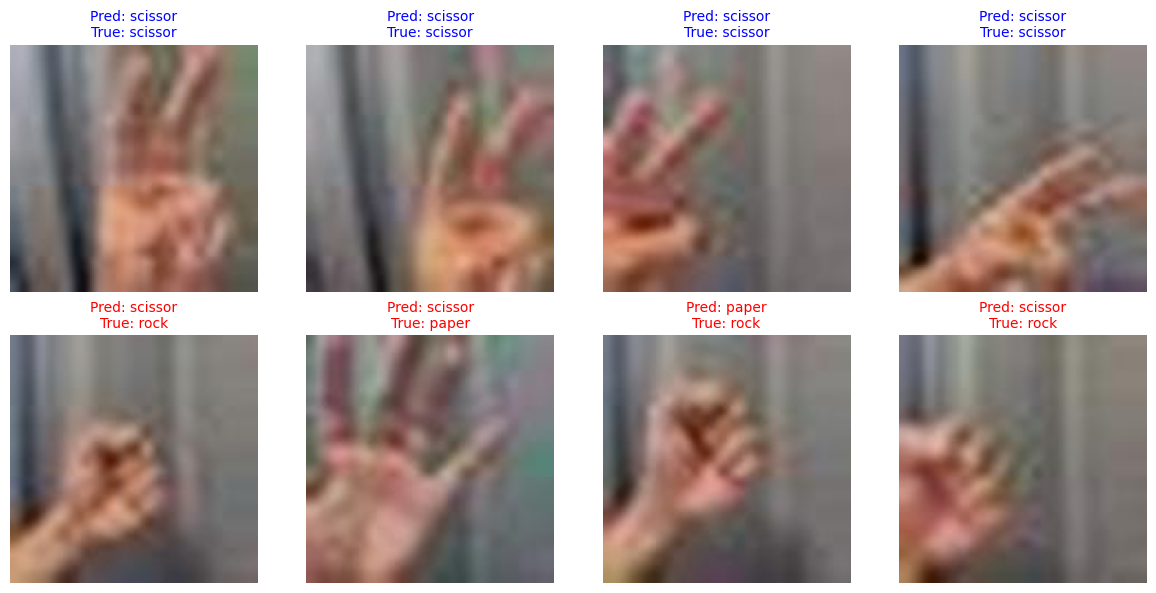

In [51]:
import matplotlib.pyplot as plt
import random

# 0, 1, 2에 해당하는 가위바위보 라벨 정의
class_names = ['scissor', 'rock', 'paper']

# 1. 모델 예측 수행 (정규화된 테스트 데이터 사용)
predicted_result = model.predict(x_test_norm)
predicted_labels = np.argmax(predicted_result, axis=1)

# 2. 정답 인덱스와 오답 인덱스 분리
correct_indices = []
wrong_indices = []

for i in range(len(y_test)):
    if predicted_labels[i] == y_test[i]:
        correct_indices.append(i)
    else:
        wrong_indices.append(i)

print(f"총 테스트 개수: {len(y_test)}")
print(f"맞춘 개수: {len(correct_indices)}, 틀린 개수: {len(wrong_indices)}")

# 3. 시각화 함수 정의
def plot_images(indices, title_str, row_idx):
    # 샘플 개수가 4개보다 적으면 있는 만큼만 가져옴
    count = min(len(indices), 4)
    # 랜덤하게 4개(또는 그 이하) 선택
    selected_indices = random.sample(indices, count)
    
    for i, idx in enumerate(selected_indices):
        plt.subplot(2, 4, row_idx * 4 + i + 1)
        plt.imshow(x_test[idx]) # 원본 이미지 출력 (정규화 전 이미지)
        plt.axis('off')
        
        # 예측 라벨과 실제 라벨 가져오기
        pred_label = class_names[predicted_labels[idx]]
        true_label = class_names[y_test[idx]]
        
        # 제목 설정 (성공/실패에 따라 색상 구분)
        color = 'blue' if predicted_labels[idx] == y_test[idx] else 'red'
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)

# 4. 결과 그리기
plt.figure(figsize=(12, 6))

# 맞춘 결과 4개 (첫 번째 줄)
if len(correct_indices) > 0:
    plot_images(correct_indices, "Correct Prediction", 0)
else:
    print("맞춘 이미지가 없습니다.")

# 틀린 결과 4개 (두 번째 줄)
if len(wrong_indices) > 0:
    plot_images(wrong_indices, "Wrong Prediction", 1)
else:
    print("틀린 이미지가 없습니다 (완벽합니다!).")

plt.tight_layout()
plt.show()